*Importando Libs e carregando datasets*

In [ ]:
import pandas as pd
import numpy as np
from google.colab import files

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="muted", font_scale=1.1)
#Os arquivos foram importados pro colab antes de iniciar a execução do notebook
df_houses = pd.read_csv("kc_house_data.csv")
df_demo = pd.read_csv("zipcode_demographics.csv")
df_future = pd.read_csv("future_unseen_examples.csv")

Visualização inicial dos datasets (printando os cabeçalhos)

In [ ]:
print("Dataset de casas:", df_houses.shape)
df_houses.head()

print("Dataset demográfico:", df_demo.shape)
df_demo.head()

Dataset de casas: (21613, 21)
Dataset demográfico: (70, 27)


,ppltn_qty,urbn_ppltn_qty,sbrbn_ppltn_qty,farm_ppltn_qty,non_farm_qty,medn_hshld_incm_amt,medn_incm_per_prsn_amt,hous_val_amt,edctn_less_than_9_qty,edctn_9_12_qty,...,per_farm,per_non_farm,per_less_than_9,per_9_to_12,per_hsd,per_some_clg,per_assoc,per_bchlr,per_prfsnl,zipcode
0,38249.0,37394.0,0.0,0.0,855.0,66051.0,25219.0,192000.0,437.0,2301.0,...,0.0,2.0,1.0,6.0,18.0,20.0,5.0,12.0,4.0,98042
1,22036.0,22036.0,0.0,0.0,0.0,91904.0,53799.0,573900.0,149.0,404.0,...,0.0,0.0,0.0,1.0,6.0,12.0,3.0,27.0,22.0,98040
2,18194.0,18194.0,0.0,0.0,0.0,61813.0,31765.0,246600.0,269.0,905.0,...,0.0,0.0,1.0,4.0,13.0,20.0,6.0,19.0,9.0,98028
3,21956.0,21956.0,0.0,0.0,0.0,47461.0,22158.0,175400.0,925.0,1773.0,...,0.0,0.0,4.0,8.0,20.0,21.0,5.0,12.0,4.0,98178
4,22814.0,22814.0,0.0,0.0,0.0,48606.0,28398.0,252600.0,599.0,1148.0,...,0.0,0.0,2.0,5.0,13.0,17.0,5.0,23.0,12.0,98007


Convertendo datas para um type entendido pelo pandas

In [ ]:
df_houses['date'] = pd.to_datetime(df_houses['date'], errors='coerce')

Mergeando datasets usando a chave zipcode

In [ ]:
df = df_houses.merge(df_demo, on="zipcode", how="left")
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,per_sbrbn,per_farm,per_non_farm,per_less_than_9,per_9_to_12,per_hsd,per_some_clg,per_assoc,per_bchlr,per_prfsnl
0,7129300520,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,0,...,0.0,0.0,0.0,4.0,8.0,20.0,21.0,5.0,12.0,4.0
1,6414100192,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0,0,...,0.0,0.0,0.0,2.0,5.0,15.0,20.0,5.0,20.0,12.0
2,5631500400,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,0,...,0.0,0.0,0.0,1.0,4.0,13.0,20.0,6.0,19.0,9.0
3,2487200875,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0,0,...,0.0,0.0,0.0,1.0,3.0,13.0,20.0,7.0,25.0,12.0
4,1954400510,2015-02-18,510000.0,3,2.00,1680,8080,1.0,0,0,...,0.0,0.0,0.0,1.0,5.0,15.0,19.0,5.0,19.0,7.5


Verificando se há dados faltantes após o merge

In [ ]:
df.isna().sum().sort_values(ascending=False)

,0
id,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0


Printando estatísticas descritivas para a análise

In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
id,21613.0,4580301520.864988,1000102.0,2123049194.0,3904930410.0,7308900445.0,9900000190.0,2876565571.312049
date,21613,2014-10-29 04:38:01.959931648,2014-05-02 00:00:00,2014-07-22 00:00:00,2014-10-16 00:00:00,2015-02-17 00:00:00,2015-05-27 00:00:00,NaN
price,21613.0,540088.141767,75000.0,321950.0,450000.0,645000.0,7700000.0,367127.196483
bedrooms,21613.0,3.370842,0.0,3.0,3.0,4.0,33.0,0.930062
bathrooms,21613.0,2.114757,0.0,1.75,2.25,2.5,8.0,0.770163
sqft_living,21613.0,2079.899736,290.0,1427.0,1910.0,2550.0,13540.0,918.440897
sqft_lot,21613.0,15106.967566,520.0,5040.0,7618.0,10688.0,1651359.0,41420.511515
floors,21613.0,1.494309,1.0,1.0,1.5,2.0,3.5,0.539989
waterfront,21613.0,0.007542,0.0,0.0,0.0,0.0,1.0,0.086517
view,21613.0,0.234303,0.0,0.0,0.0,0.0,4.0,0.766318


Plotando dados importantes

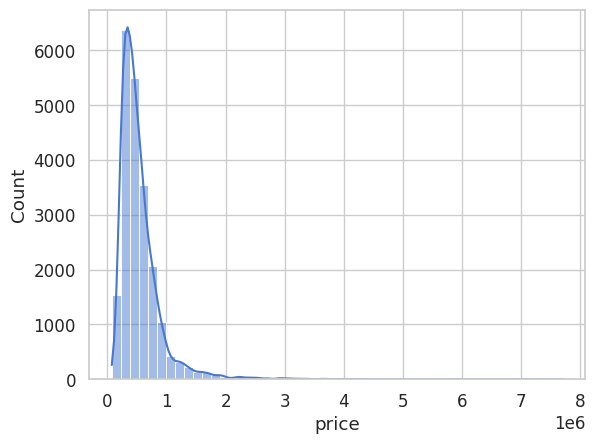

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["price"], bins=50, kde=True)
plt.show()


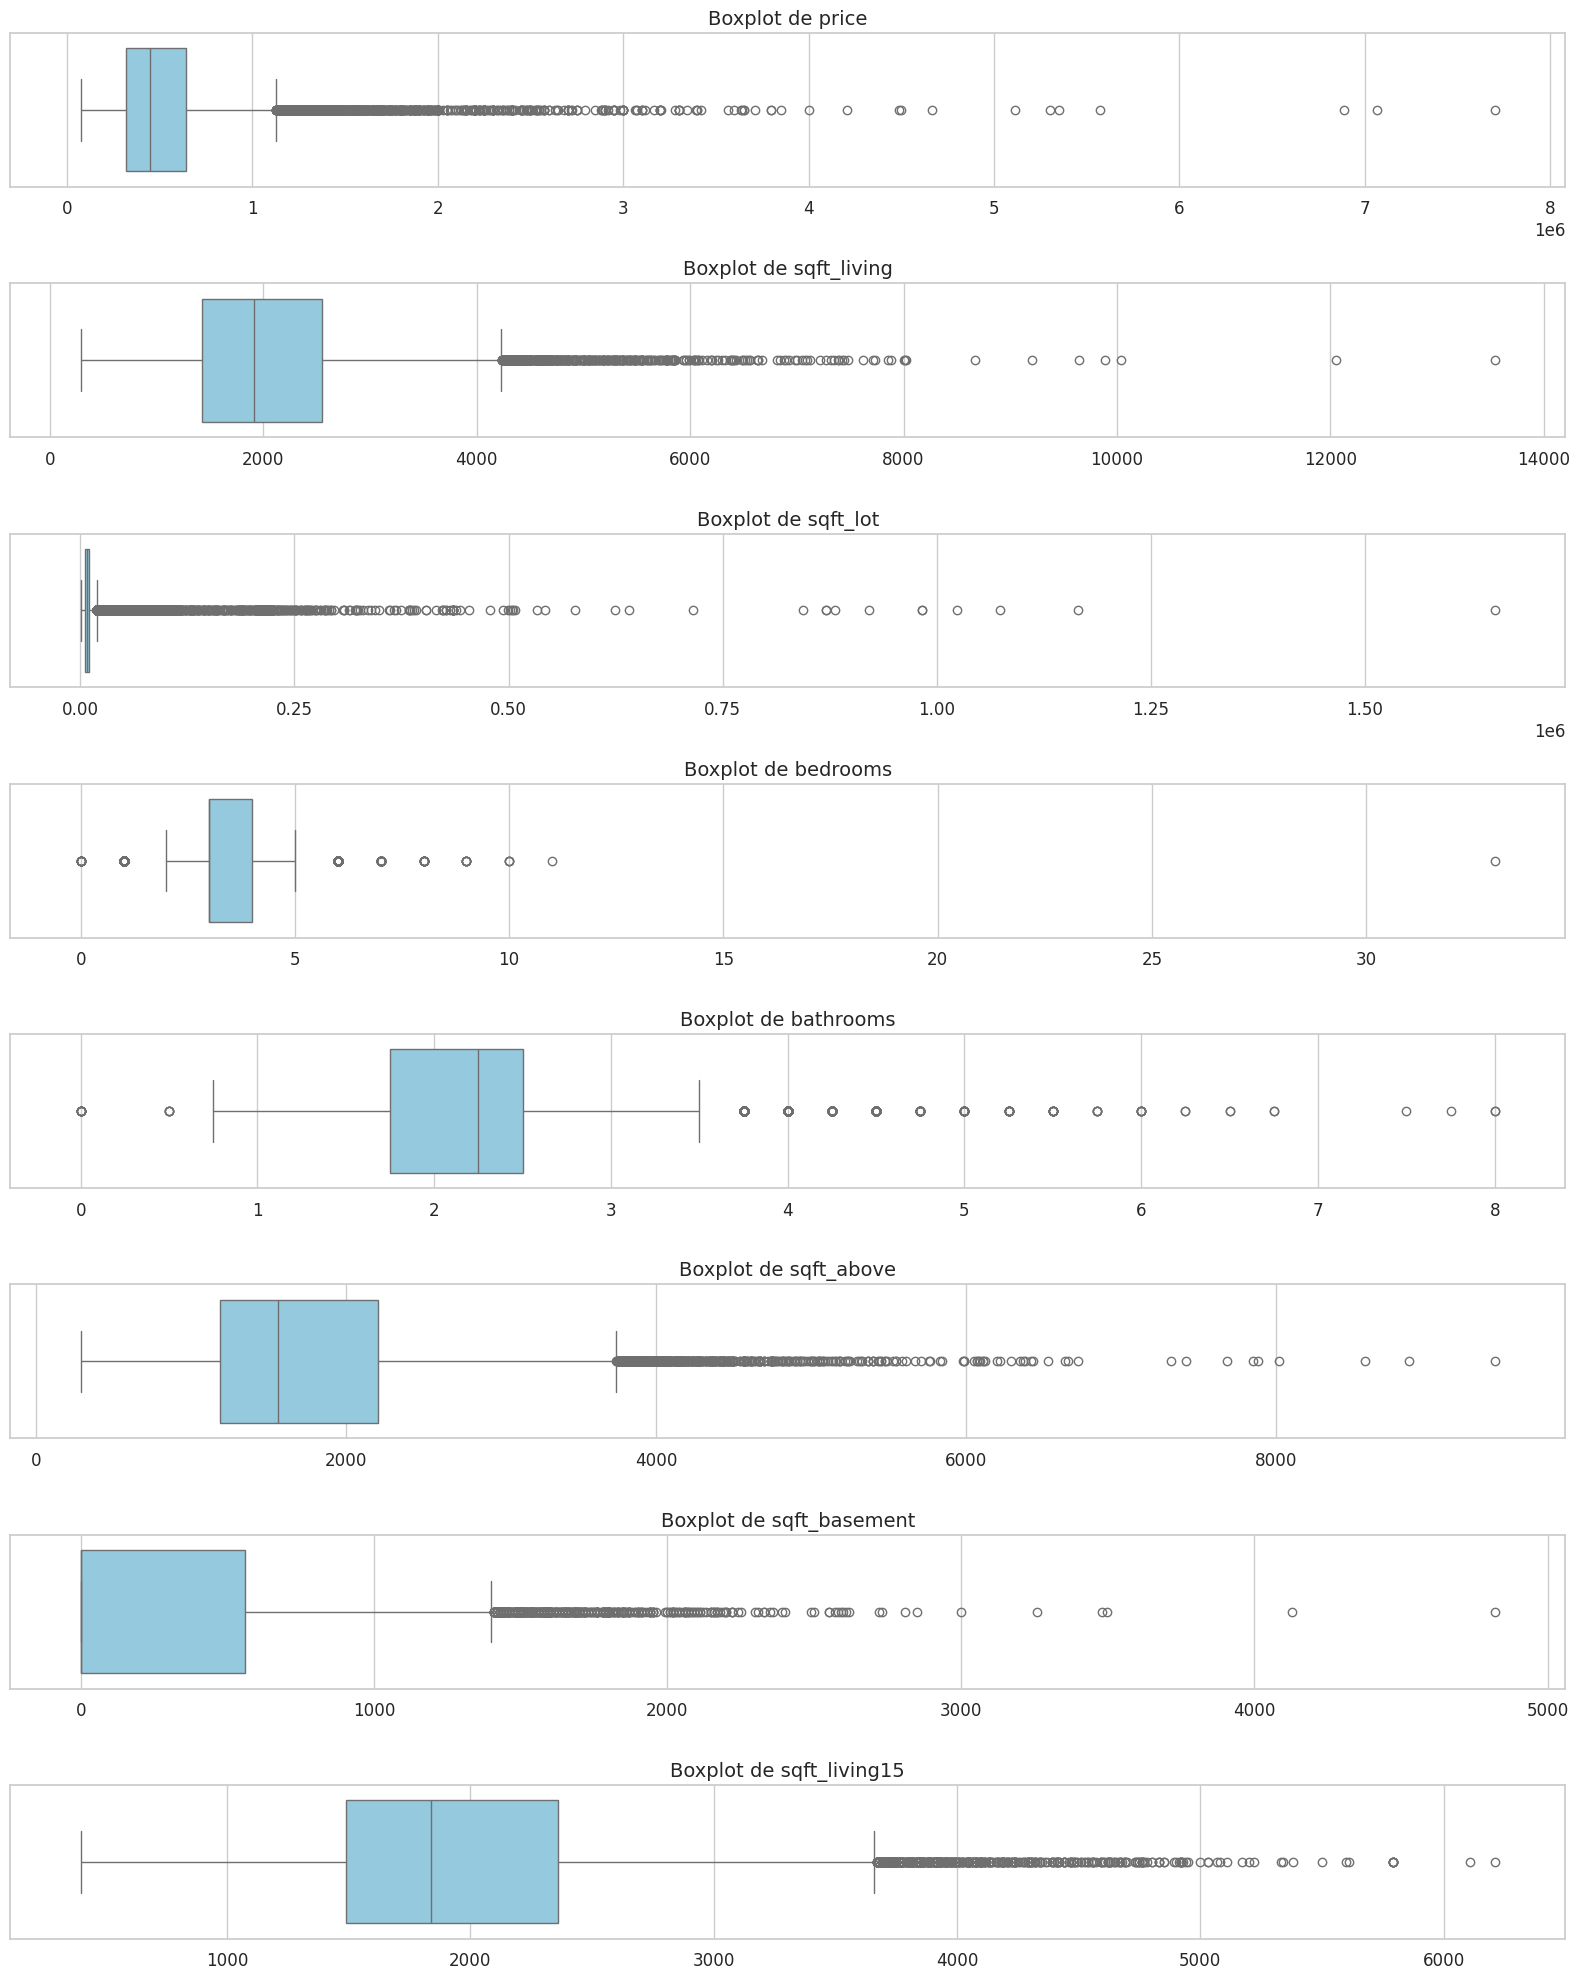

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

features_para_boxplot = [
    'price', 'sqft_living', 'sqft_lot', 'bedrooms', 'bathrooms',
    'sqft_above', 'sqft_basement', 'sqft_living15'
]

plt.figure(figsize=(16, 20))

for i, col in enumerate(features_para_boxplot, 1):
    plt.subplot(len(features_para_boxplot), 1, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot de {col}', fontsize=14)
    plt.xlabel("")
    plt.tight_layout()
plt.show()

Limpando outliers que parecem absurdos

Linhas restantes após limpeza: 21595


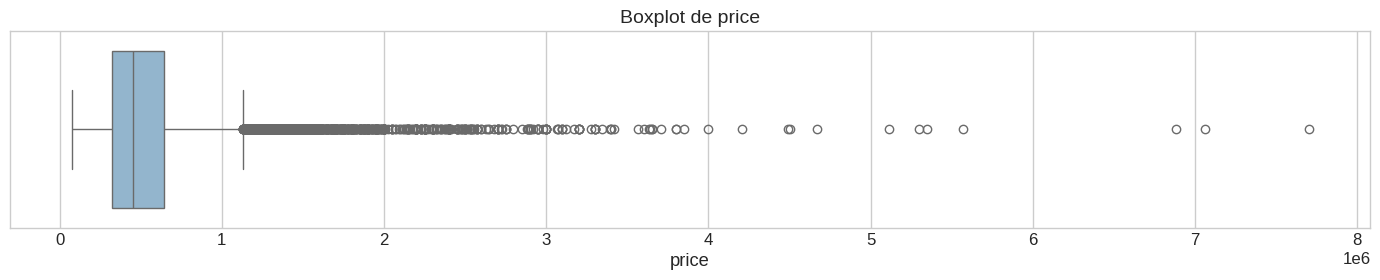

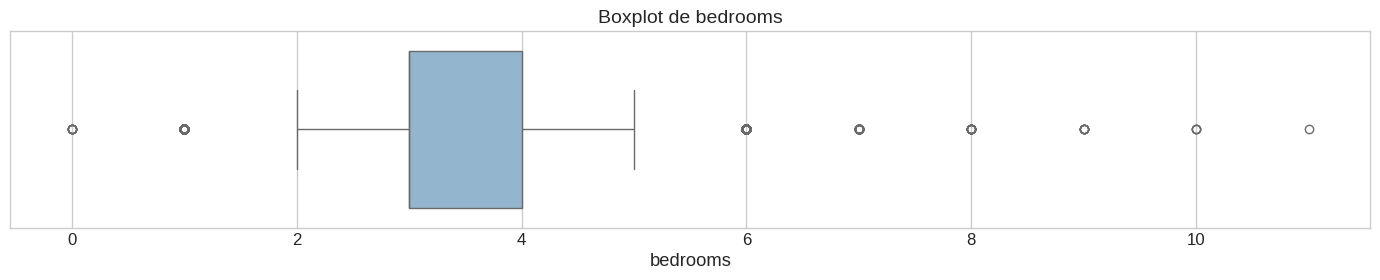

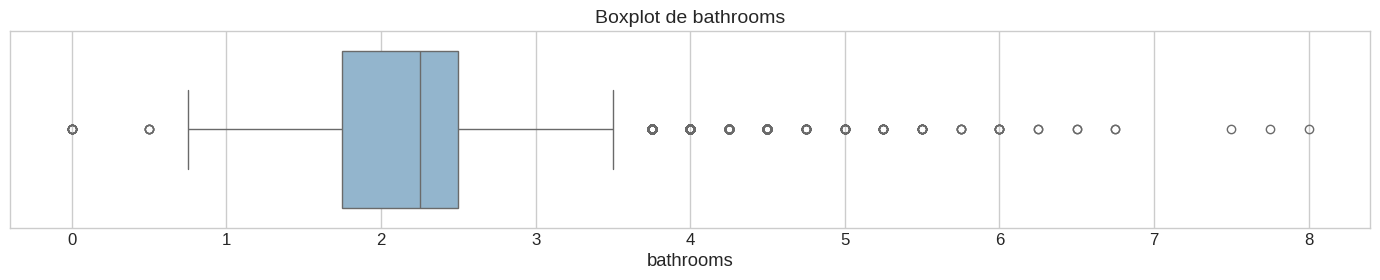

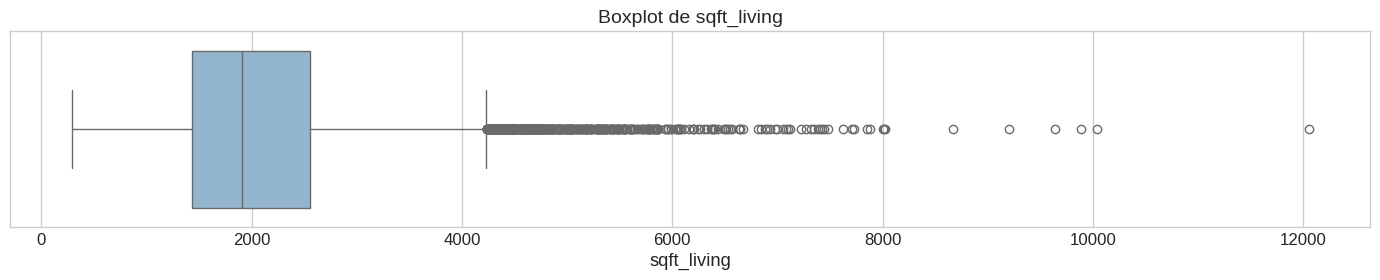

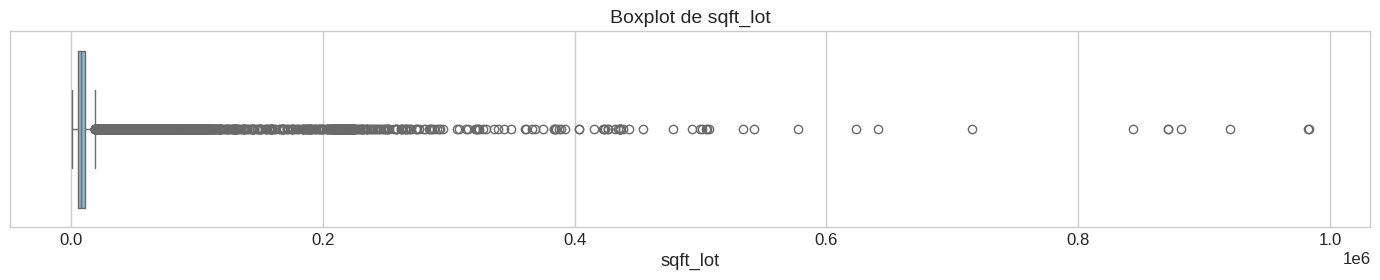

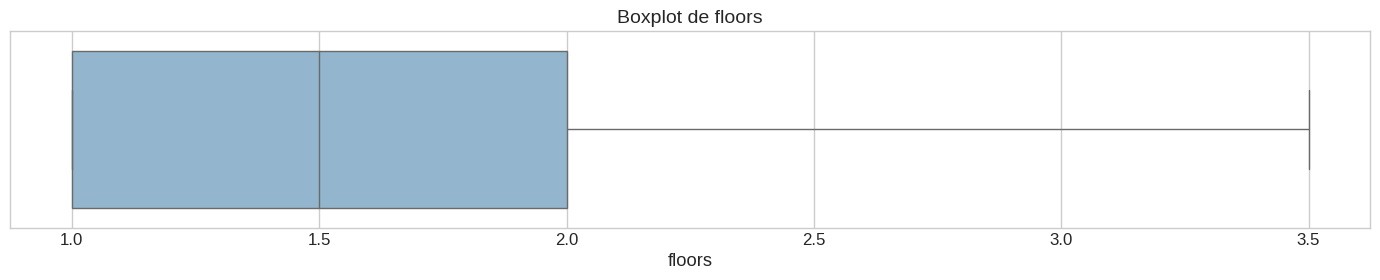

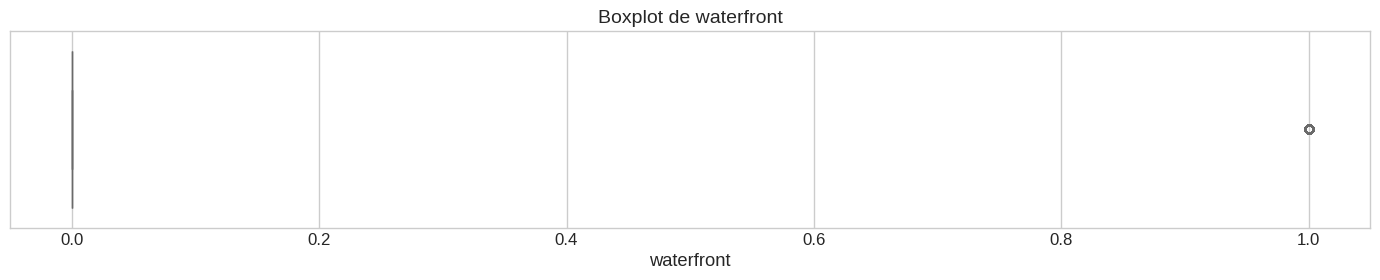

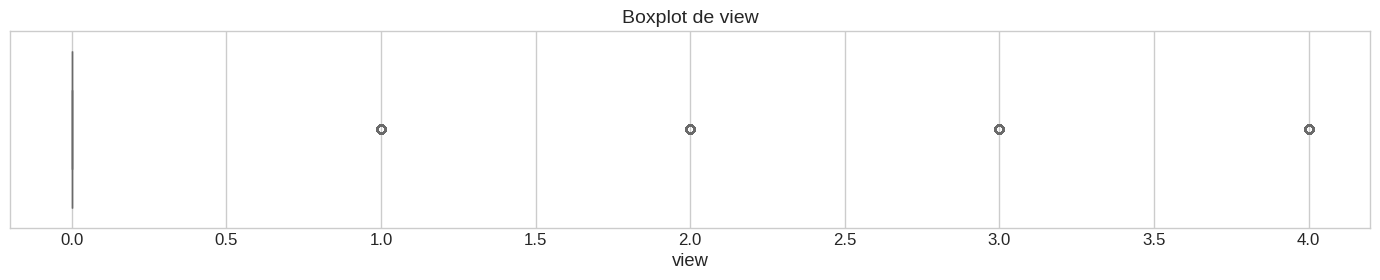

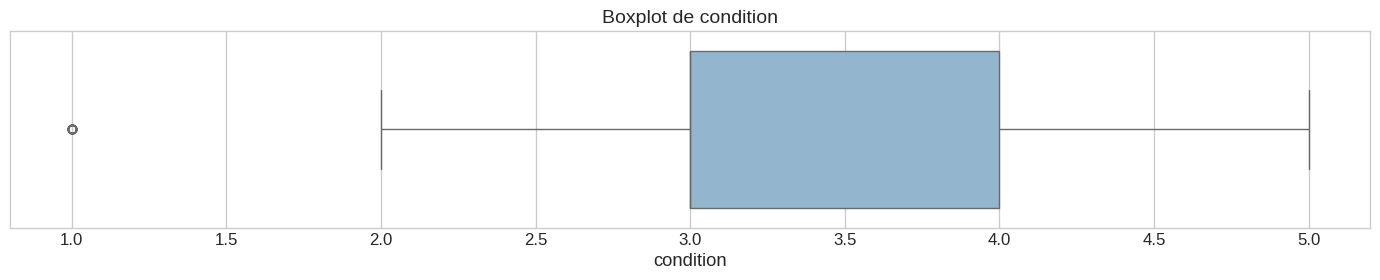

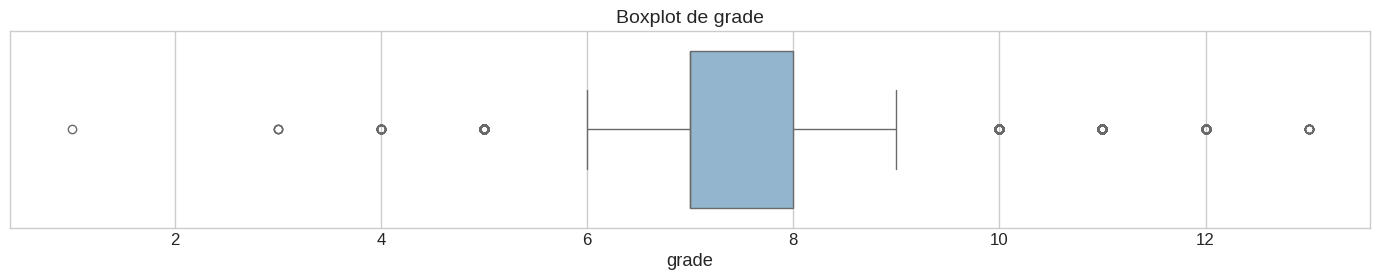

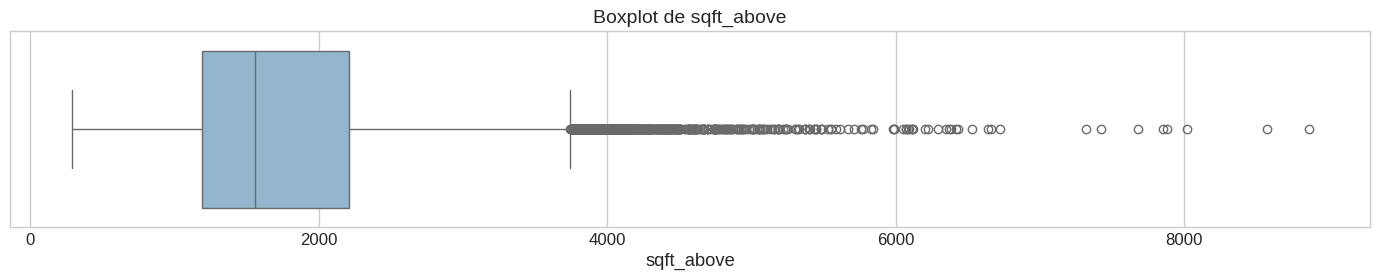

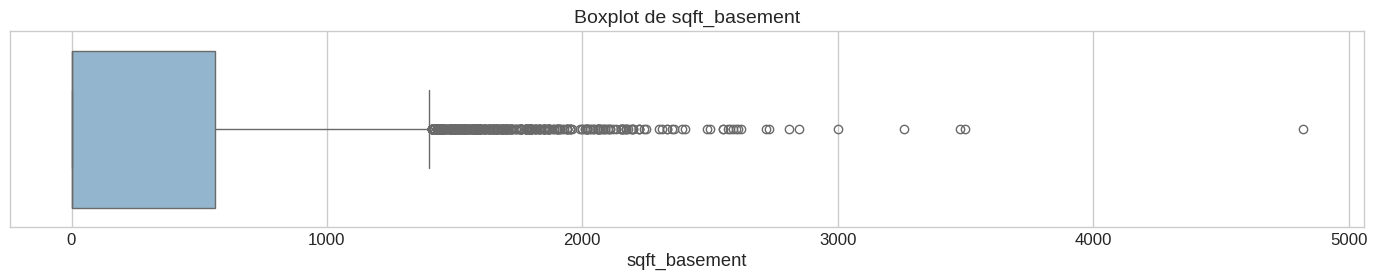

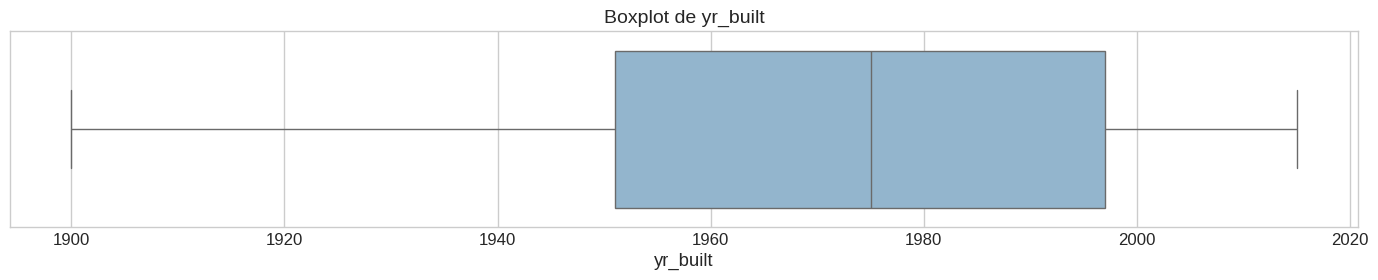

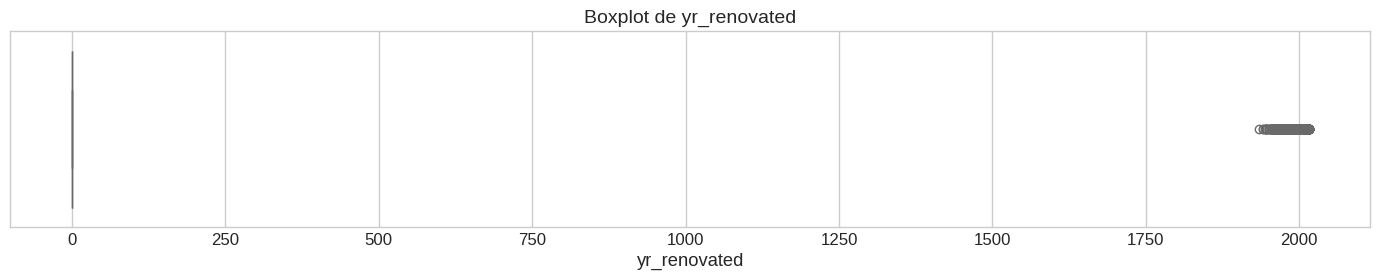

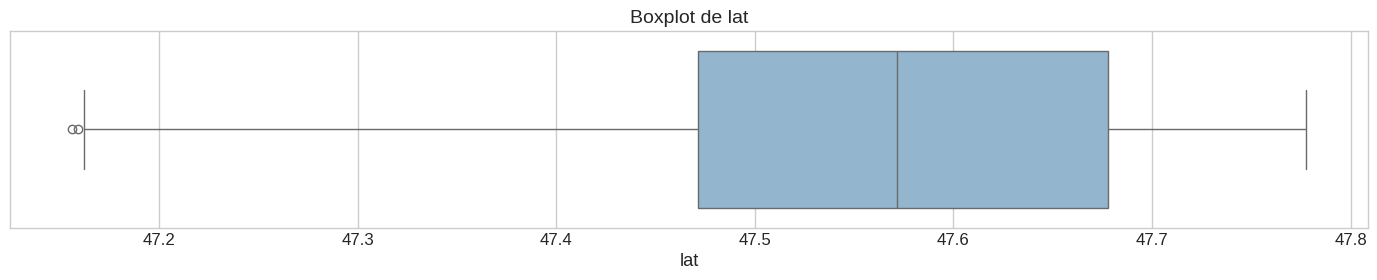

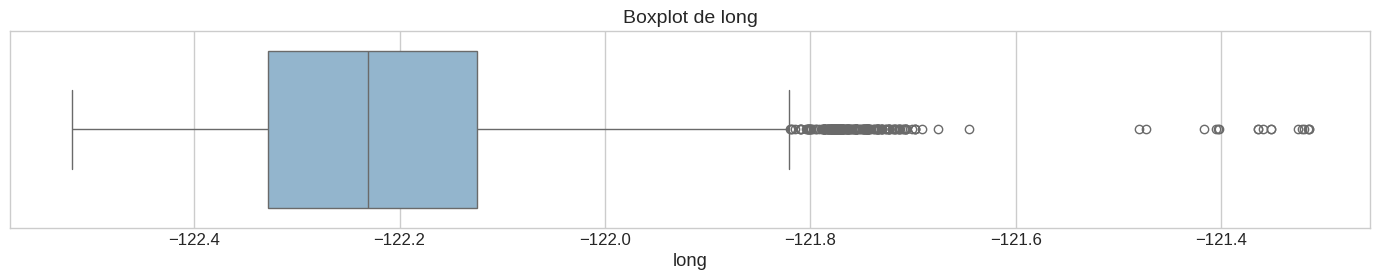

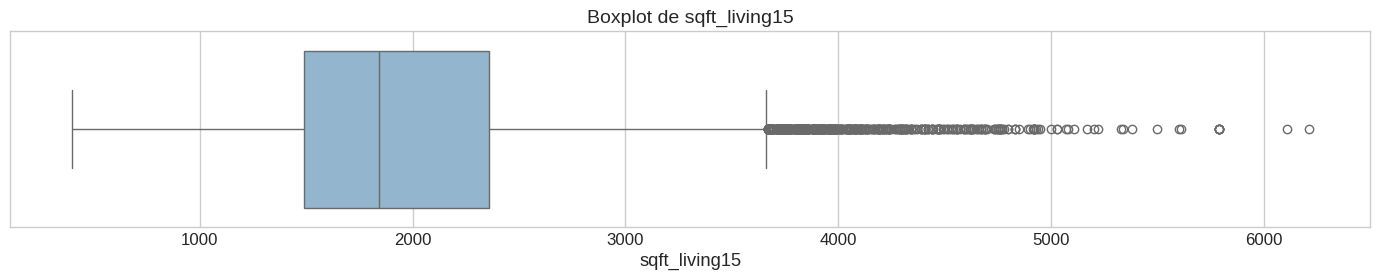

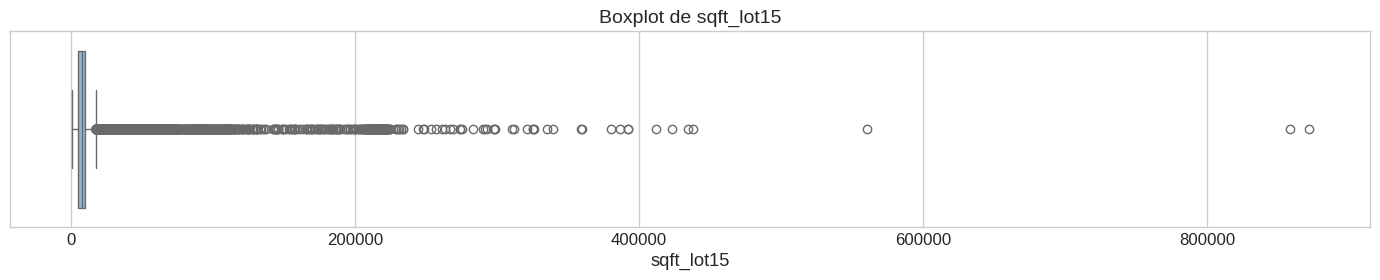

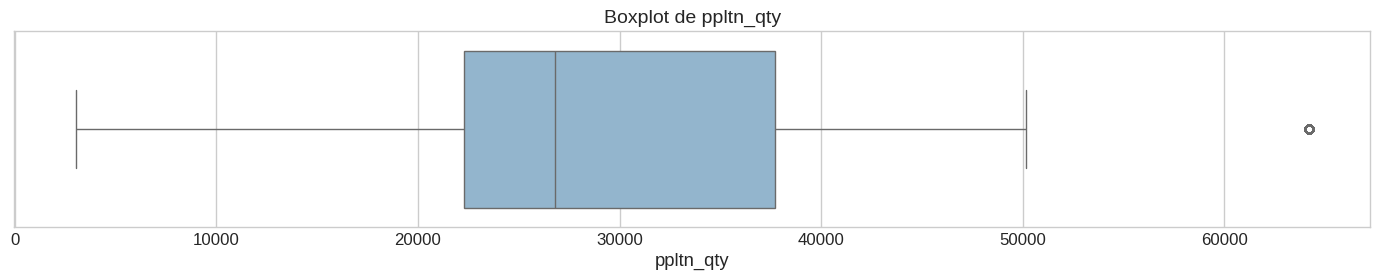

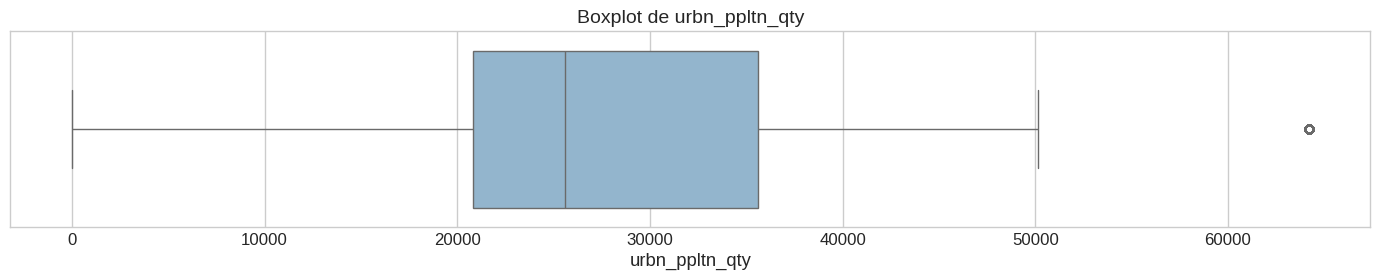

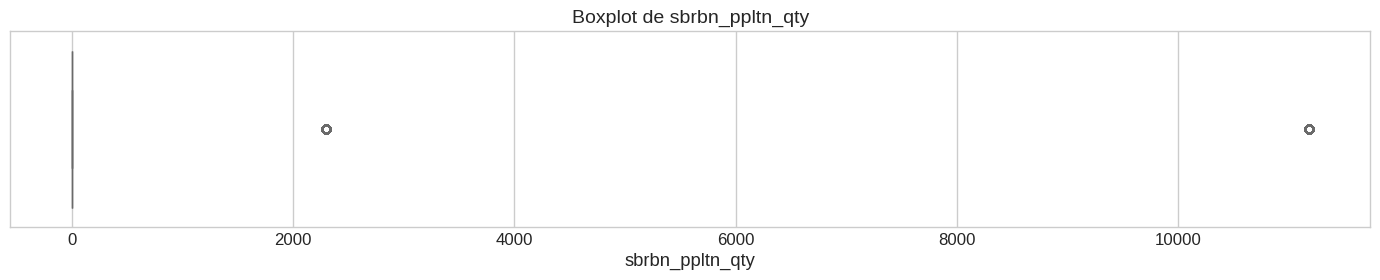

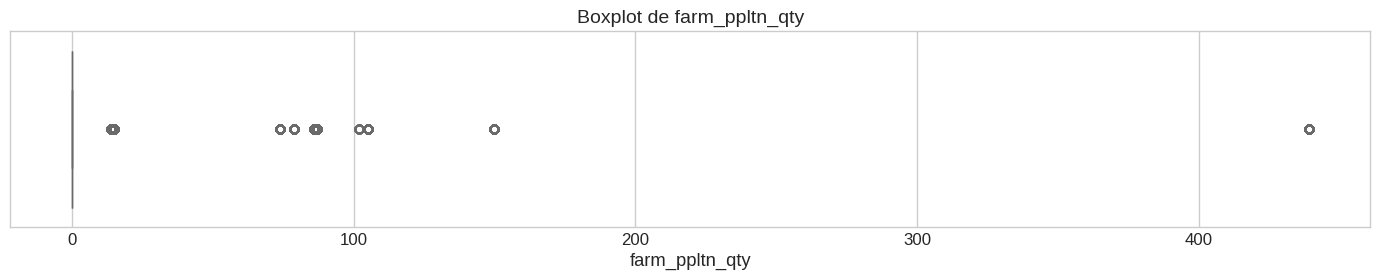

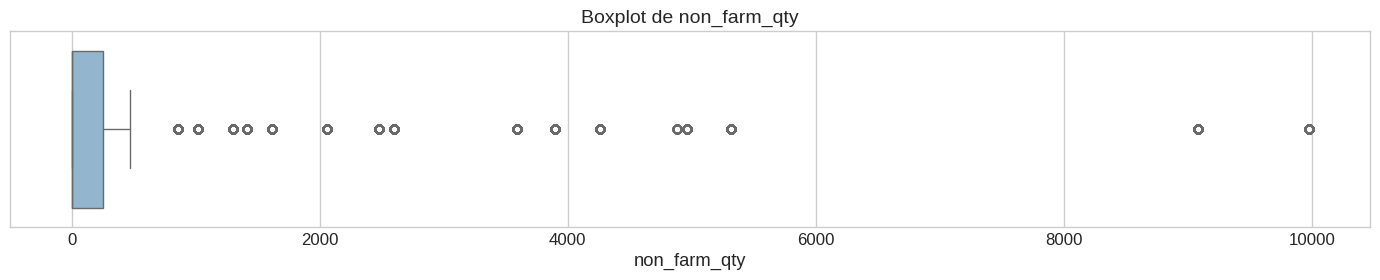

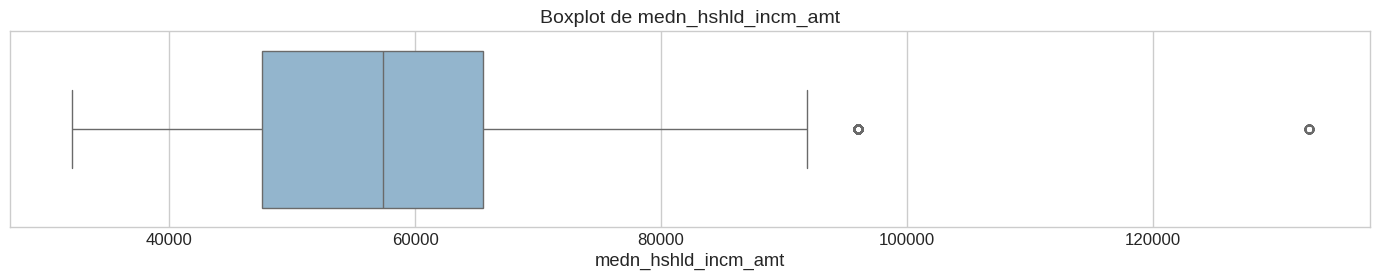

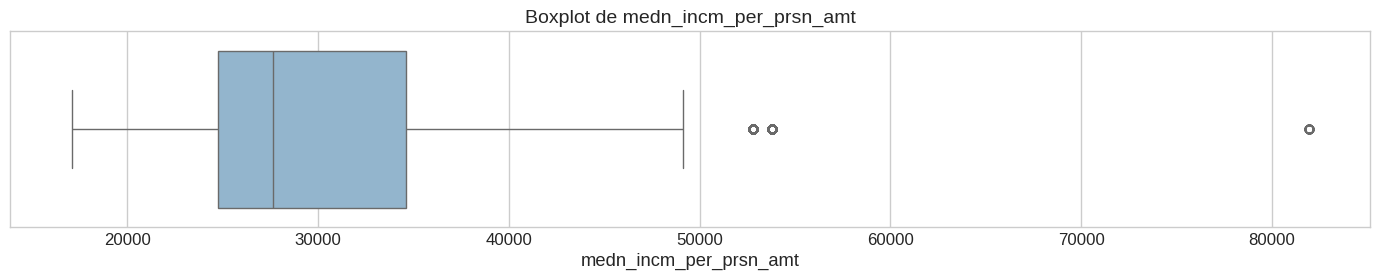

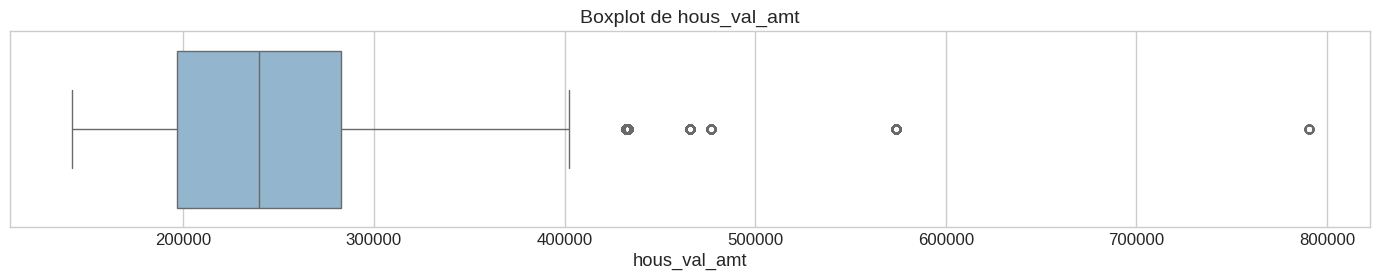

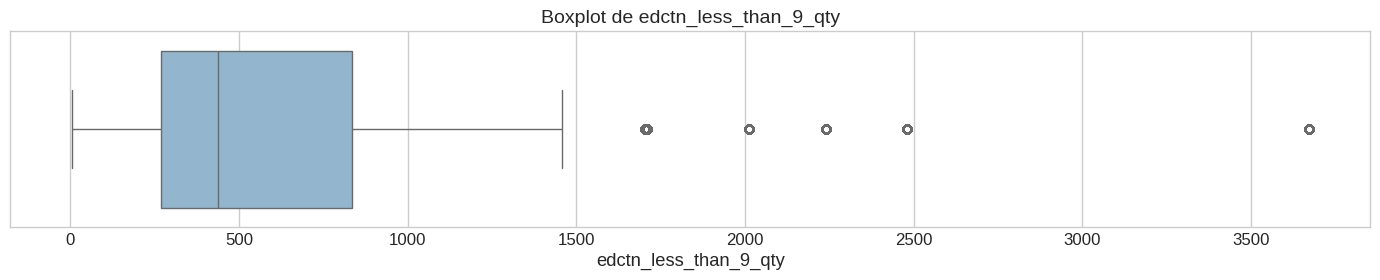

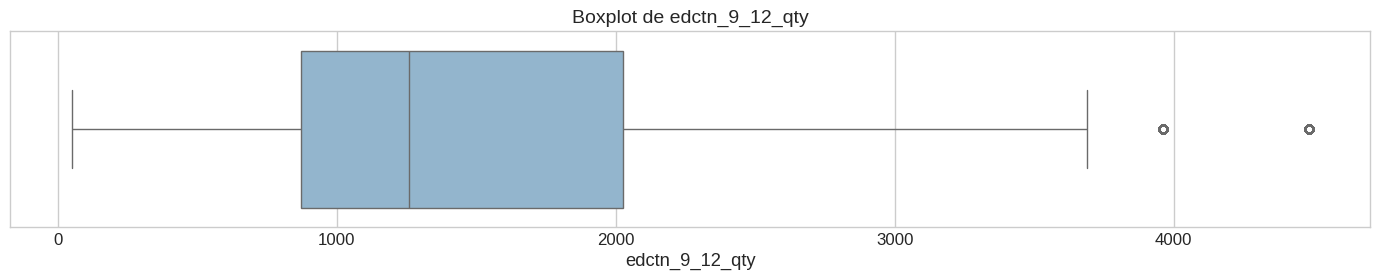

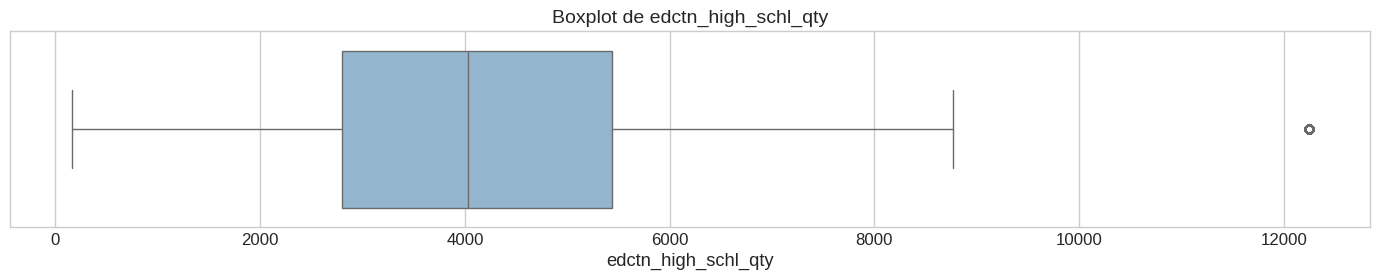

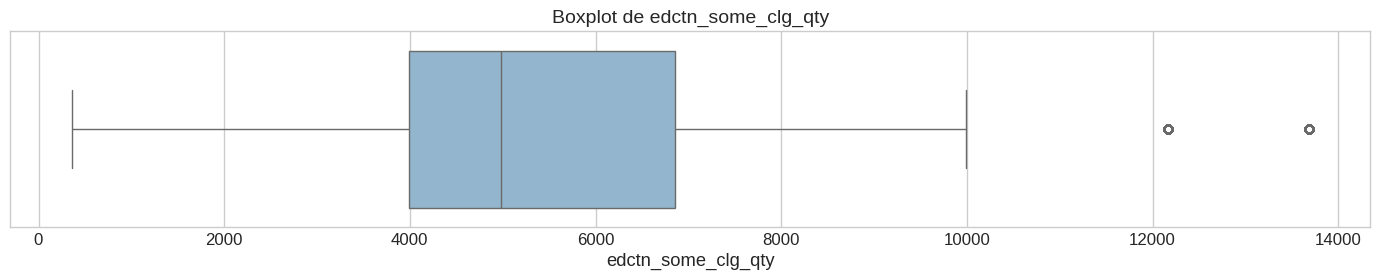

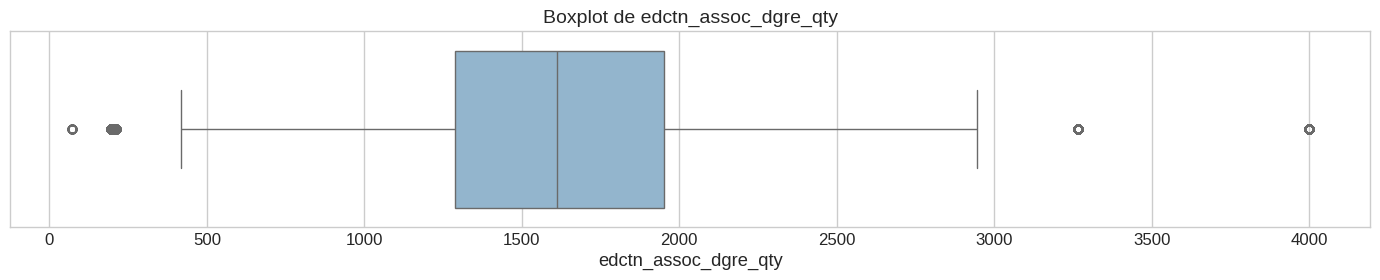

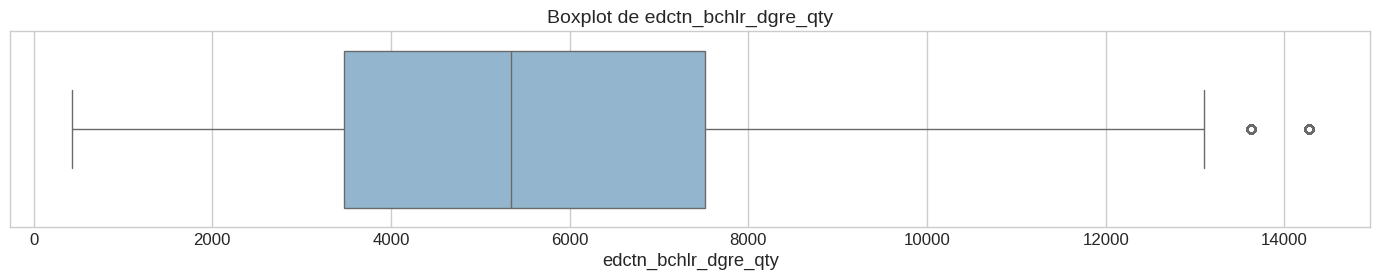

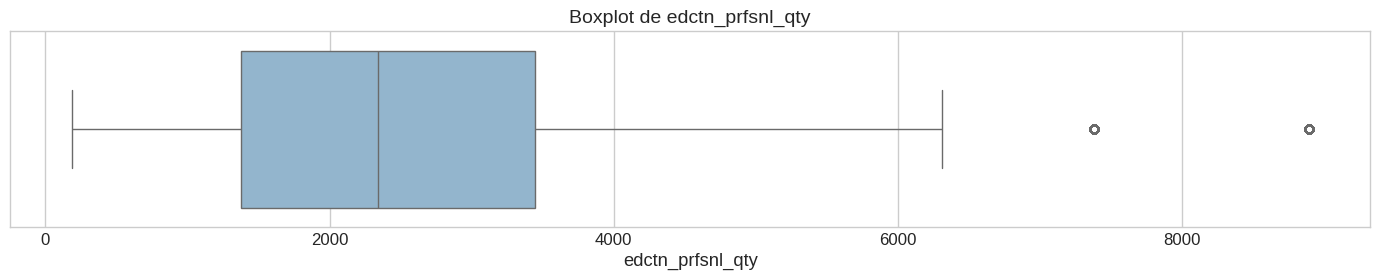

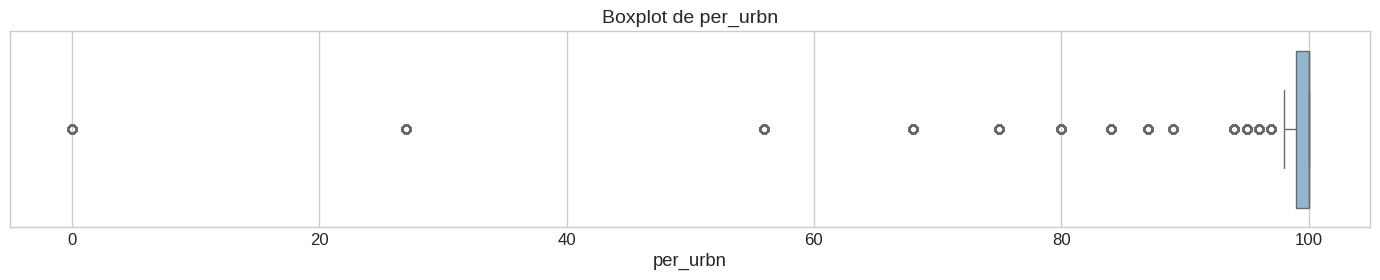

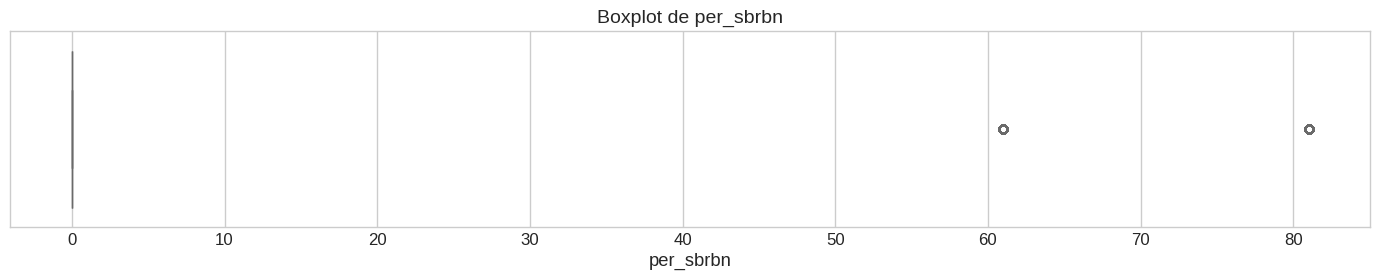

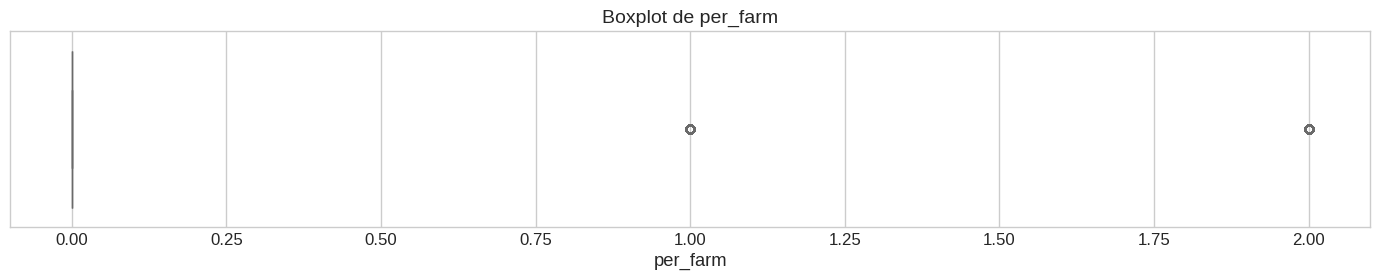

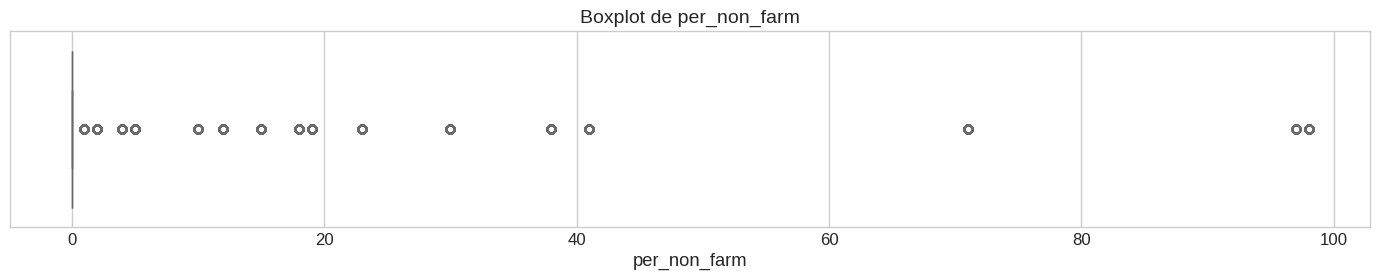

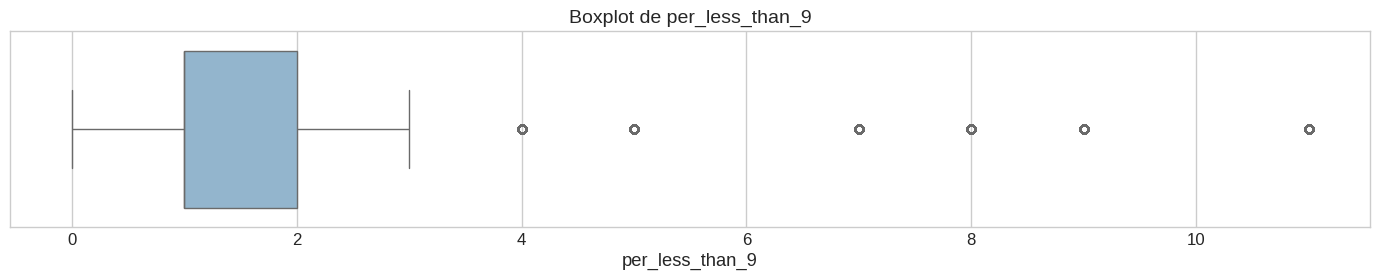

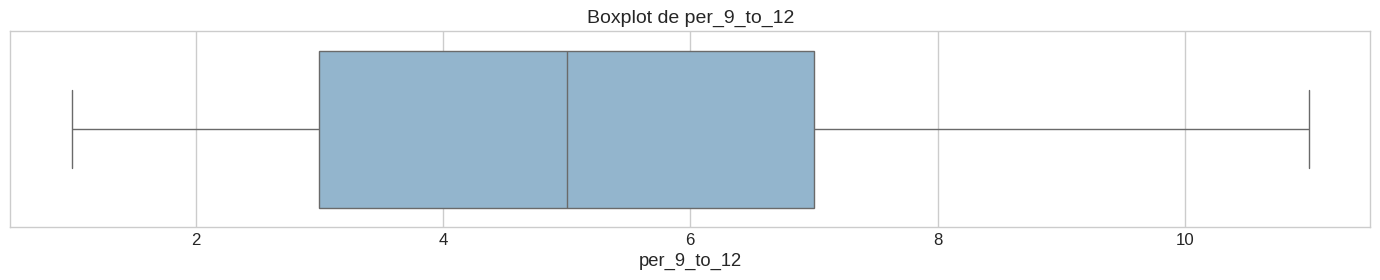

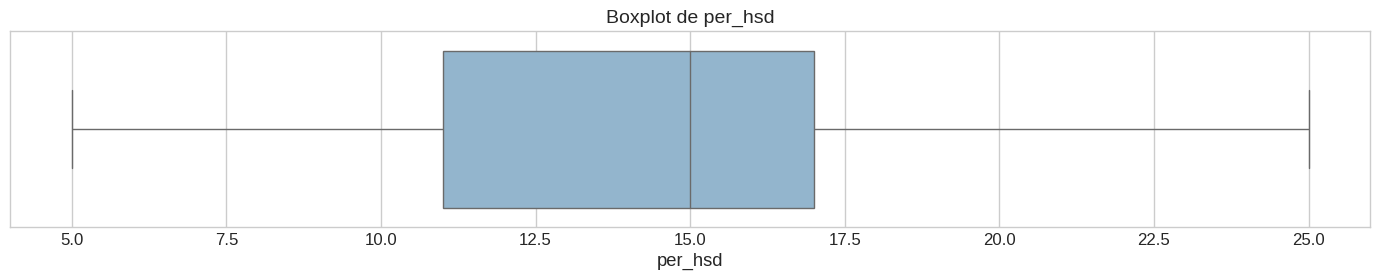

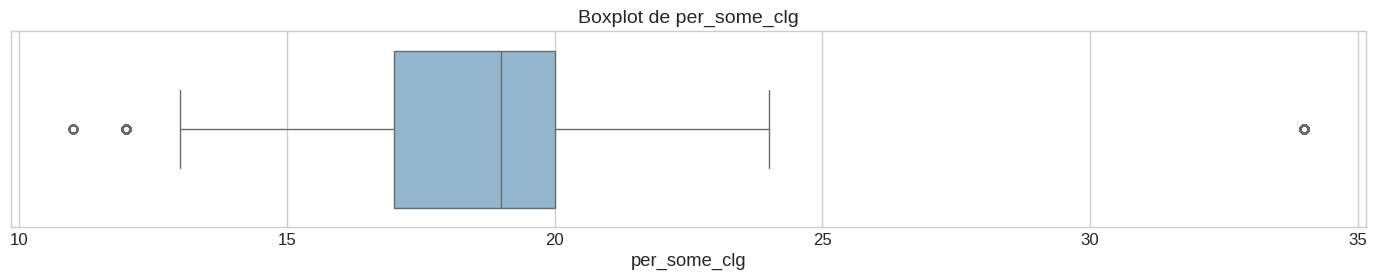

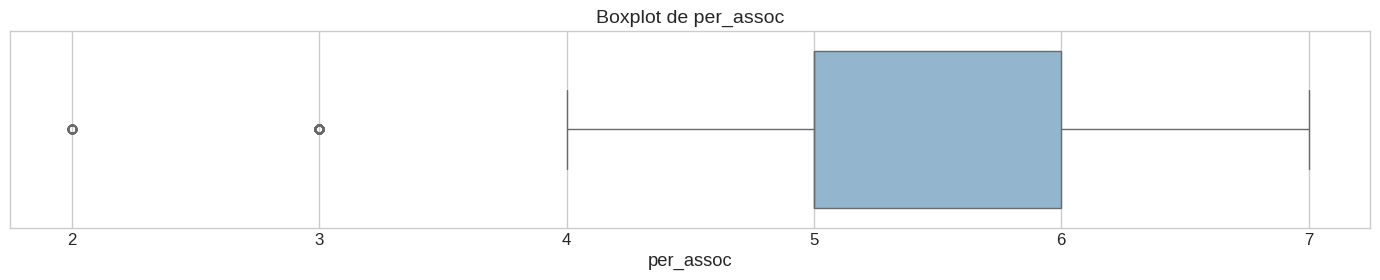

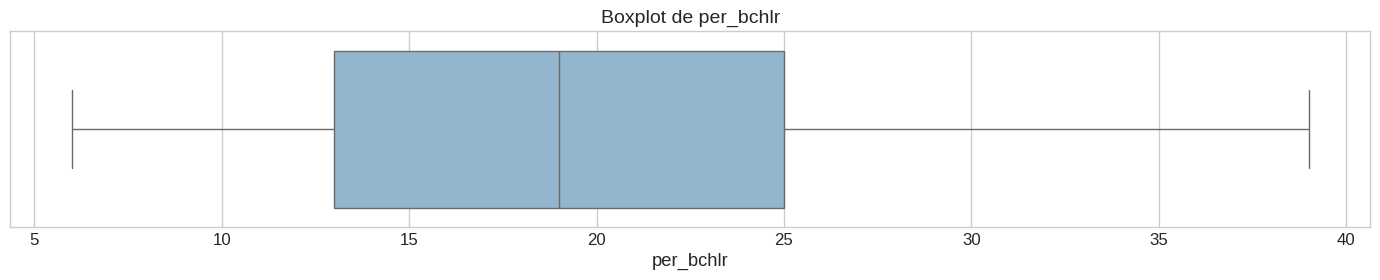

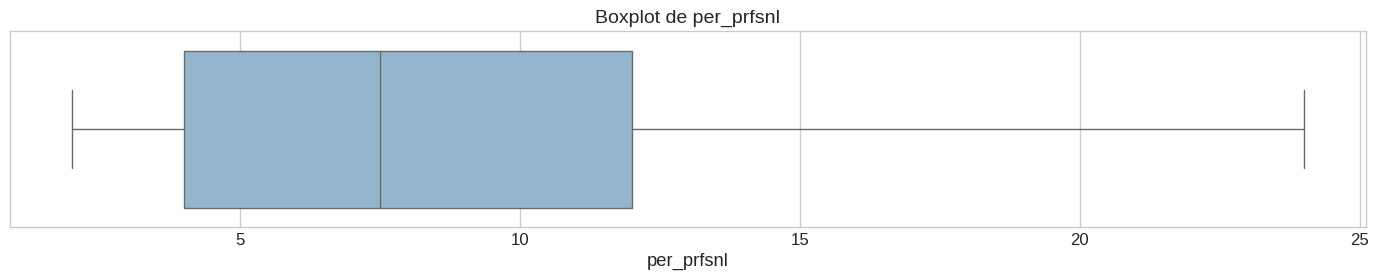

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def clean_impossible_outliers(df):
    df = df.copy()


    df = df[df['bedrooms'] <= 15]
    df = df[df['bathrooms'] <= 10]
    df = df[df['sqft_living'] <= 13000]
    df = df[df['sqft_lot'] <= 1000000]
    df = df[df['price'] <= 8_000_000]
    df = df[df['yr_built'] >= 1850]
    df = df[df['yr_renovated'] <= 2024]
    df = df[df['floors'] <= 4]

    # ----------- Regras cruzadas -----------
    df = df[df['bathrooms'] <= df['bedrooms'] * 2]
    df = df[df['sqft_above'] <= df['sqft_living']]
    df = df[df['sqft_basement'] <= 5000]
    df = df[df['sqft_living'] >= df['bedrooms'] * 100]
    df = df[df['sqft_living'] >= df['bathrooms'] * 50]

    return df


df_clean = clean_impossible_outliers(df)
print(f"Linhas restantes após limpeza: {df_clean.shape[0]}")
cols = df_clean.select_dtypes(include='number').columns.tolist()

cols_to_remove = ["id", "zipcode"]
cols = [c for c in cols if c not in cols_to_remove]

plt.style.use('seaborn-v0_8-whitegrid')

for col in cols:
    plt.figure(figsize=(14, 3))
    sns.boxplot(x=df_clean[col], color="#8ab6d6")
    plt.title(f"Boxplot de {col}", fontsize=14)
    plt.tight_layout()
    plt.show()

Plotando corelações

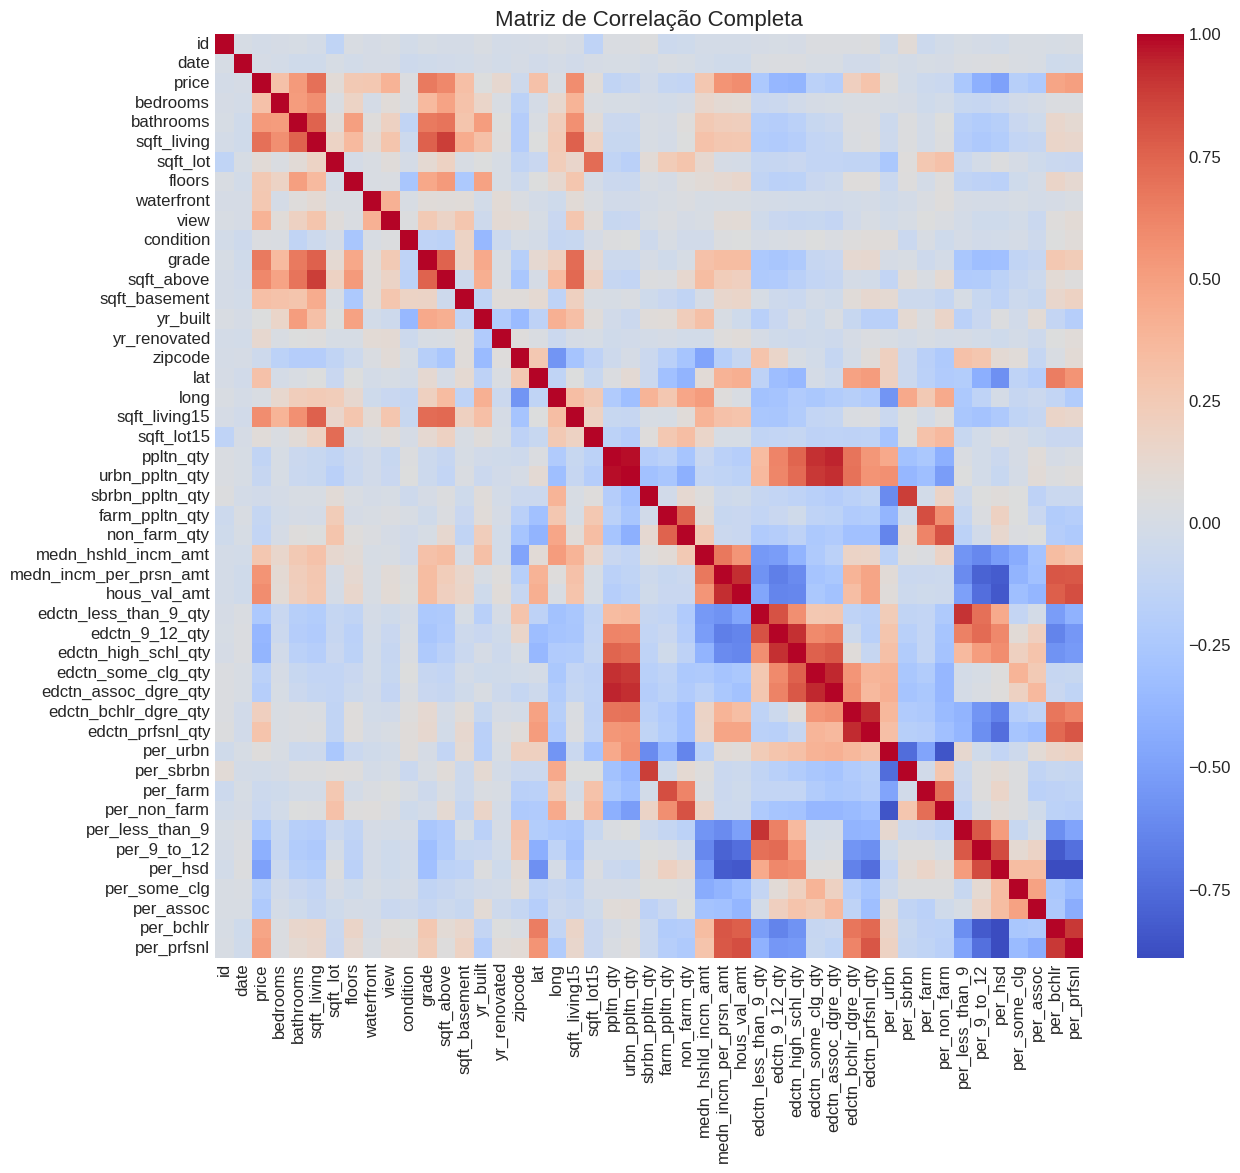

,price
price,1.000000
sqft_living,0.702035
grade,0.667434
sqft_above,0.605567
sqft_living15,0.585379
hous_val_amt,0.579733
medn_incm_per_prsn_amt,0.549911
bathrooms,0.525138
per_prfsnl,0.500262
per_bchlr,0.474896


In [ ]:
plt.figure(figsize=(14,12))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Matriz de Correlação Completa", fontsize=16)
plt.savefig("correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
df.corr()["price"].sort_values(ascending=False)

In [ ]:
df_clean.to_csv("df_final.csv", index=False)
df_clean.columns
files.download("df_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>